# P6 Step GPU Optimization — Branch Length Estimation

Comparing the **P6 step** GPU build against all previous builds:
- **GPU P5 (Persistent Tip State)** — previous best GPU
- **GPU maxregcount** — register-count optimization
- **GPU Baseline** (V100, standard OpenACC)
- **CPU backends**: VANILA (1-core), OMP_10, OMP_48

Models: AA/LG and DNA/GTR (unrooted)  
100 taxa, 1M sites, 10 trees, 10 runs each

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

P6_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_p6_step')
P5_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_persistent_tip_state')
OPT_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_branch_length_estimation_opt')
BASELINE_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_branch_length_estimation')
SAVE_DIR = Path('.')

## 1. Parse All Log Files

In [2]:
def parse_log(filepath):
    try:
        with open(filepath, 'r') as f:
            text = f.read()
    except Exception:
        return None
    result = {}
    m = re.search(r'Total wall-clock time used:\s+([\d.]+)\s+sec', text)
    if m: result['walltime'] = float(m.group(1))
    m = re.search(r'Total CPU time used:\s+([\d.]+)\s+sec', text)
    if m: result['cputime'] = float(m.group(1))
    m = re.search(r'BEST SCORE FOUND\s*:\s*([\-\d.]+)', text)
    if m: result['log_likelihood'] = float(m.group(1))
    m = re.search(r'Total tree length:\s+([\d.]+)', text)
    if m: result['tree_length'] = float(m.group(1))
    m = re.search(r'Parameters optimization took \d+ rounds \(([\d.]+) sec\)', text)
    if m: result['opt_time'] = float(m.group(1))
    return result if 'walltime' in result else None

def extract_run_number(filename):
    matches = re.findall(r'_run(\d+)_', filename)
    return int(matches[-1]) if matches else None

def classify_backend(filename):
    if 'OPENACC' in filename: return 'OPENACC'
    elif 'VANILA' in filename: return 'VANILA'
    elif 'OMP_48' in filename: return 'OMP_48'
    elif 'OMP_10' in filename: return 'OMP_10'
    return 'UNKNOWN'

def parse_results_dir(base_dir, backend_override=None, skip_profile=True):
    rows = []
    for data_type in ['AA', 'DNA']:
        for tree_type in ['rooted', 'unrooted']:
            type_dir = base_dir / data_type / tree_type
            if not type_dir.exists(): continue
            for model_dir in sorted(type_dir.iterdir()):
                if not model_dir.is_dir(): continue
                model = model_dir.name
                for tree_dir in sorted(model_dir.iterdir()):
                    if not tree_dir.is_dir(): continue
                    tree = tree_dir.name
                    for logfile in tree_dir.glob('*.log'):
                        fname = logfile.name
                        if skip_profile and 'profile' in fname.lower(): continue
                        backend = backend_override if backend_override else classify_backend(fname)
                        run_num = extract_run_number(fname)
                        metrics = parse_log(logfile)
                        if metrics:
                            rows.append({'data_type': data_type, 'tree_type': tree_type,
                                        'model': model, 'tree': tree, 'backend': backend,
                                        'run': run_num, **metrics})
    return rows

In [3]:
# Parse all sources
rows_p6 = parse_results_dir(P6_DIR, backend_override='GPU_P6')
rows_p5 = parse_results_dir(P5_DIR, backend_override='GPU_P5')
rows_opt = parse_results_dir(OPT_DIR, backend_override='GPU_MAXREG')
rows_base = parse_results_dir(BASELINE_DIR)

df_p6 = pd.DataFrame(rows_p6)
df_p5 = pd.DataFrame(rows_p5)
df_opt = pd.DataFrame(rows_opt)
df_base = pd.DataFrame(rows_base)

# Filter baseline to AA/LG and DNA/GTR, unrooted
df_base = df_base[
    (df_base['tree_type'] == 'unrooted') &
    (((df_base['data_type'] == 'AA') & (df_base['model'] == 'LG')) |
     ((df_base['data_type'] == 'DNA') & (df_base['model'] == 'GTR')))
].copy()

df = pd.concat([df_base, df_opt, df_p5, df_p6], ignore_index=True)
df.to_csv(SAVE_DIR / 'results_all.csv', index=False)

print(f'GPU P6:       {len(df_p6)} entries')
print(f'GPU P5:       {len(df_p5)} entries')
print(f'GPU maxreg:   {len(df_opt)} entries')
print(f'Baseline:     {len(df_base)} entries')
print(f'\nCombined: {len(df)} entries')
print(df.groupby(['data_type', 'backend']).size().unstack(fill_value=0))

GPU P6:       200 entries
GPU P5:       179 entries
GPU maxreg:   120 entries
Baseline:     687 entries

Combined: 1186 entries
backend    GPU_MAXREG  GPU_P5  GPU_P6  OMP_10  OMP_48  OPENACC  VANILA
data_type                                                             
AA                 70      99     100     100     100      137      20
DNA                50      80     100     100     100       90      40


## 2. Summary Statistics

In [4]:
summary = df.groupby(['data_type', 'model', 'backend']).agg(
    walltime_mean=('walltime', 'mean'),
    walltime_median=('walltime', 'median'),
    walltime_std=('walltime', 'std'),
    walltime_min=('walltime', 'min'),
    walltime_max=('walltime', 'max'),
    opt_time_mean=('opt_time', 'mean'),
    logl_mean=('log_likelihood', 'mean'),
    logl_std=('log_likelihood', 'std'),
    tree_length_mean=('tree_length', 'mean'),
    tree_length_std=('tree_length', 'std'),
    n_runs=('walltime', 'count')
).round(3)
summary.to_csv(SAVE_DIR / 'results_summary.csv')
summary

walltime_mean  walltime_median  walltime_std  \
data_type model backend                                                    
AA        LG    GPU_MAXREG         29.486           30.248         2.329   
                GPU_P5             17.671           18.286         1.312   
                GPU_P6             17.710           18.308         1.313   
                OMP_10             40.597           38.558         9.580   
                OMP_48             15.457           15.020         2.398   
                OPENACC            29.859           30.599         2.427   
                VANILA            251.787          250.290        33.784   
DNA       GTR   GPU_MAXREG         48.685           48.264         5.991   
                GPU_P5             25.050           23.621         3.414   
                GPU_P6             34.605           30.839         6.791   
                OMP_10             38.111           34.237        14.922   
                OMP_48             16.185           15.054         4.098   
                OPENACC            50.172           49.356         6.565   
                VANILA            133.017          121.995        22.931   

                            walltime_min  walltime_max  opt_time_mean  \
data_type model backend                                                 
AA        LG    GPU_MAXREG        23.393        31.885         26.588   
                GPU_P5            14.970        18.545         14.799   
                GPU_P6            14.989        18.680         14.853   
                OMP_10            28.444        67.275         39.260   
                OMP_48            11.250        20.561         14.026   
                OPENACC           23.594        32.290         26.954   
                VANILA           212.665       291.329        248.778   
DNA       GTR   GPU_MAXREG        42.190        60.852         45.921   
                GPU_P5            21.213        31.858         22.236   
                GPU_P6            27.892        47.566         31.798   
                OMP_10            19.758        92.248         36.906   
                OMP_48             9.970        24.545         15.061   
                OPENACC           43.421        63.452         47.367   
                VANILA           111.904       177.733        130.275   

                               logl_mean     logl_std  tree_length_mean  \
data_type model backend                                                   
AA        LG    GPU_MAXREG -8.747060e+07  1812371.109            19.720   
                GPU_P5     -8.632411e+07  2618006.962            19.352   
                GPU_P6     -8.632801e+07  2605043.269            19.351   
                OMP_10     -8.632801e+07  2605043.269            19.351   
                OMP_48     -8.632801e+07  2605043.269            19.351   
                OPENACC    -8.747797e+07  1824949.805            19.719   
                VANILA     -8.970307e+07   822470.828            20.130   
DNA       GTR   GPU_MAXREG -6.683769e+07  1560312.560            19.746   
                GPU_P5     -6.655753e+07  1944873.717            19.490   
                GPU_P6     -6.743701e+07  2633938.757            19.912   
                OMP_10     -6.743701e+07  2633938.757            19.912   
                OMP_48     -6.743701e+07  2633938.757            19.912   
                OPENACC    -6.670245e+07  1579812.307            19.703   
                VANILA     -6.653339e+07  1607473.986            19.648   

                            tree_length_std  n_runs  
data_type model backend                              
AA        LG    GPU_MAXREG            0.569      70  
                GPU_P5                0.797      99  
                GPU_P6                0.793     100  
                OMP_10                0.793     100  
                OMP_48                0.793     100  
                OPENACC               0.573     137  
         

## 3. Likelihood Comparison
Detailed verification that P6 produces identical results to all other backends.

In [5]:
# Per-tree, per-backend likelihood values
logl_detail = df.groupby(['data_type', 'model', 'tree', 'backend']).agg(
    logl_mean=('log_likelihood', 'mean'),
    logl_std=('log_likelihood', 'std'),
    tree_length_mean=('tree_length', 'mean'),
    tree_length_std=('tree_length', 'std'),
    n=('log_likelihood', 'count')
).round(6).reset_index()
logl_detail.to_csv(SAVE_DIR / 'likelihood_per_tree_backend.csv', index=False)

# Pivot for side-by-side view
logl_pivot = logl_detail.pivot_table(index=['data_type', 'model', 'tree'],
                                      columns='backend', values='logl_mean').reset_index()
print('Log-likelihood per tree per backend:')
display(logl_pivot.round(3))

Log-likelihood per tree per backend:


backend,data_type,model,tree,GPU_MAXREG,GPU_P5,GPU_P6,OMP_10,OMP_48,OPENACC,VANILA
0,AA,LG,tree_1,-8.890142e+07,-8.890142e+07,-8.890142e+07,-8.890142e+07,-8.890142e+07,-8.890142e+07,-8.890142e+07
1,AA,LG,tree_10,NaN,-8.671423e+07,-8.671423e+07,-8.671423e+07,-8.671423e+07,NaN,NaN
2,AA,LG,tree_2,-9.050471e+07,-9.050471e+07,-9.050471e+07,-9.050471e+07,-9.050471e+07,-9.050471e+07,-9.050471e+07
3,AA,LG,tree_3,-8.735700e+07,-8.735700e+07,-8.735700e+07,-8.735700e+07,-8.735700e+07,-8.735700e+07,NaN
4,AA,LG,tree_4,-8.771263e+07,-8.771263e+07,-8.771263e+07,-8.771263e+07,-8.771263e+07,-8.771263e+07,NaN
5,AA,LG,tree_5,-8.638277e+07,-8.638277e+07,-8.638277e+07,-8.638277e+07,-8.638277e+07,-8.638277e+07,NaN
6,AA,LG,tree_6,-8.430150e+07,-8.430150e+07,-8.430150e+07,-8.430150e+07,-8.430150e+07,-8.430150e+07,NaN
7,AA,LG,tree_7,-8.713416e+07,-8.713416e+07,-8.713416e+07,-8.713416e+07,-8.713416e+07,-8.713416e+07,NaN
8,AA,LG,tree_8,NaN,-8.193152e+07,-8.193152e+07,-8.193152e+07,-8.193152e+07,NaN,NaN
9,AA,LG,tree_9,NaN,-8.234019e+07,-8.234019e+07,-8.234019e+07,-8.234019e+07,NaN,NaN


In [6]:
# Compute differences: P6 vs every other backend
diff_cols = []
for b in ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC', 'GPU_MAXREG', 'GPU_P5']:
    if b in logl_pivot.columns and 'GPU_P6' in logl_pivot.columns:
        col = f'P6_minus_{b}'
        logl_pivot[col] = (logl_pivot['GPU_P6'] - logl_pivot[b]).round(6)
        diff_cols.append(col)

print('Likelihood differences (GPU_P6 - other backend):')
print('0.0 = identical')
display(logl_pivot[['data_type', 'model', 'tree'] + diff_cols])
logl_pivot.to_csv(SAVE_DIR / 'likelihood_comparison.csv', index=False)

Likelihood differences (GPU_P6 - other backend):
0.0 = identical


backend,data_type,model,tree,P6_minus_VANILA,P6_minus_OMP_10,P6_minus_OMP_48,P6_minus_OPENACC,P6_minus_GPU_MAXREG,P6_minus_GPU_P5
0,AA,LG,tree_1,0.0,0.0,0.0,0.0,0.0,0.0
1,AA,LG,tree_10,NaN,0.0,0.0,NaN,NaN,0.0
2,AA,LG,tree_2,0.0,0.0,0.0,0.0,0.0,0.0
3,AA,LG,tree_3,NaN,0.0,0.0,0.0,0.0,0.0
4,AA,LG,tree_4,NaN,0.0,0.0,0.0,0.0,0.0
5,AA,LG,tree_5,NaN,0.0,0.0,0.0,0.0,0.0
6,AA,LG,tree_6,NaN,0.0,0.0,0.0,0.0,0.0
7,AA,LG,tree_7,NaN,0.0,0.0,0.0,0.0,0.0
8,AA,LG,tree_8,NaN,0.0,0.0,NaN,NaN,0.0
9,AA,LG,tree_9,NaN,0.0,0.0,NaN,NaN,0.0


In [7]:
# Overall range check across ALL backends per tree
logl_range = df.groupby(['data_type', 'model', 'tree']).agg(
    logl_min=('log_likelihood', 'min'),
    logl_max=('log_likelihood', 'max'),
    logl_range=('log_likelihood', lambda x: x.max() - x.min()),
    tl_min=('tree_length', 'min'),
    tl_max=('tree_length', 'max'),
    tl_range=('tree_length', lambda x: x.max() - x.min())
).reset_index()
logl_range.to_csv(SAVE_DIR / 'likelihood_range_check.csv', index=False)

logl_mismatch = logl_range[logl_range['logl_range'] > 0.01]
tl_mismatch = logl_range[logl_range['tl_range'] > 0.001]

print(f'Log-likelihood mismatches (range > 0.01): {len(logl_mismatch)}')
if len(logl_mismatch) > 0:
    display(logl_mismatch)
else:
    print('  ✓ All backends (including P6) produce identical log-likelihoods.')

print(f'\nTree length mismatches (range > 0.001): {len(tl_mismatch)}')
if len(tl_mismatch) > 0:
    display(tl_mismatch)
else:
    print('  ✓ All backends produce identical tree lengths.')

Log-likelihood mismatches (range > 0.01): 0
  ✓ All backends (including P6) produce identical log-likelihoods.

Tree length mismatches (range > 0.001): 0
  ✓ All backends produce identical tree lengths.


## 4. Wall-clock Time — All Backends

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_18592/2304012451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_18592/2304012451.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)


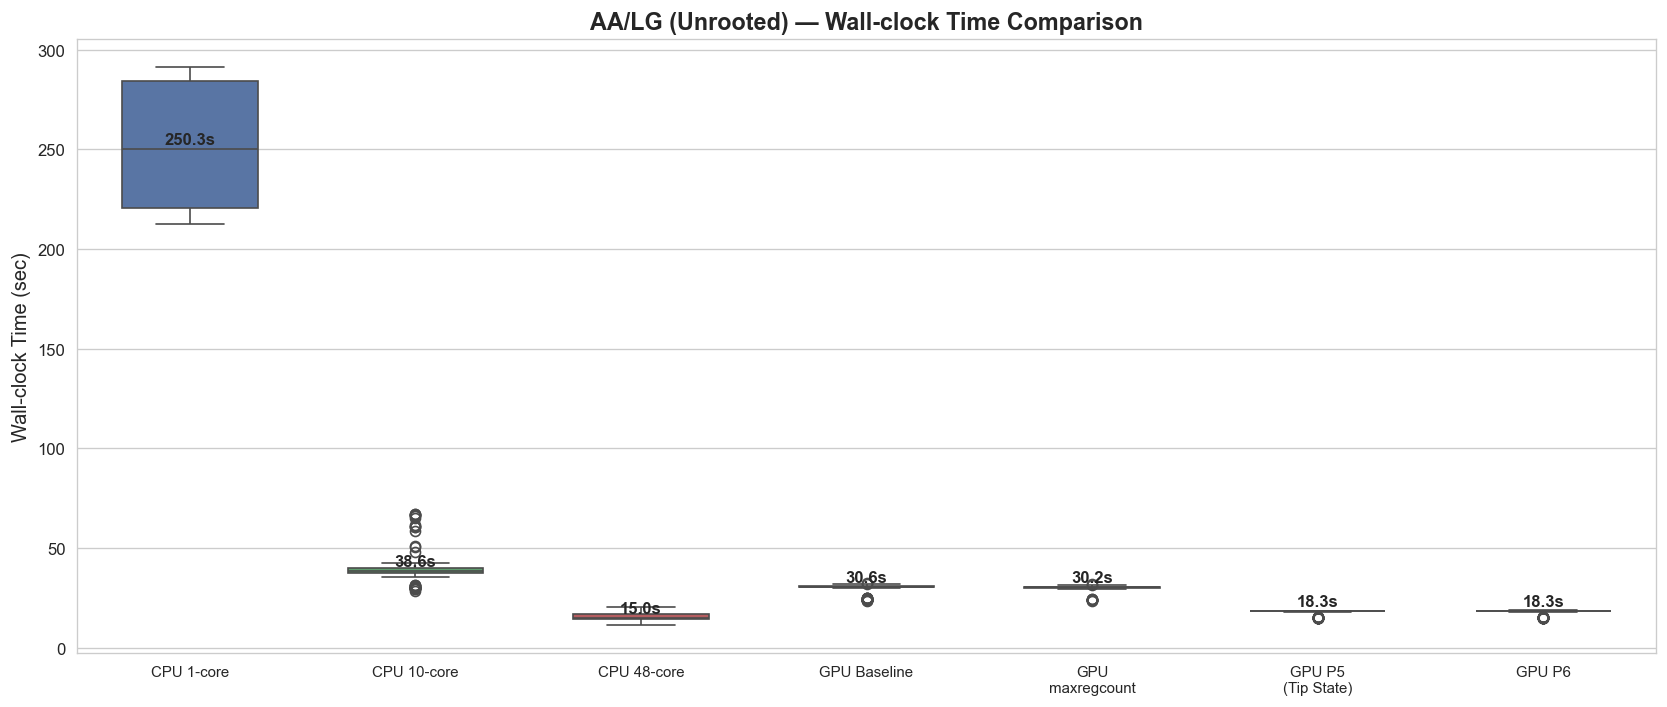

Saved: walltime_all_AA_LG.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_18592/2304012451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_18592/2304012451.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)


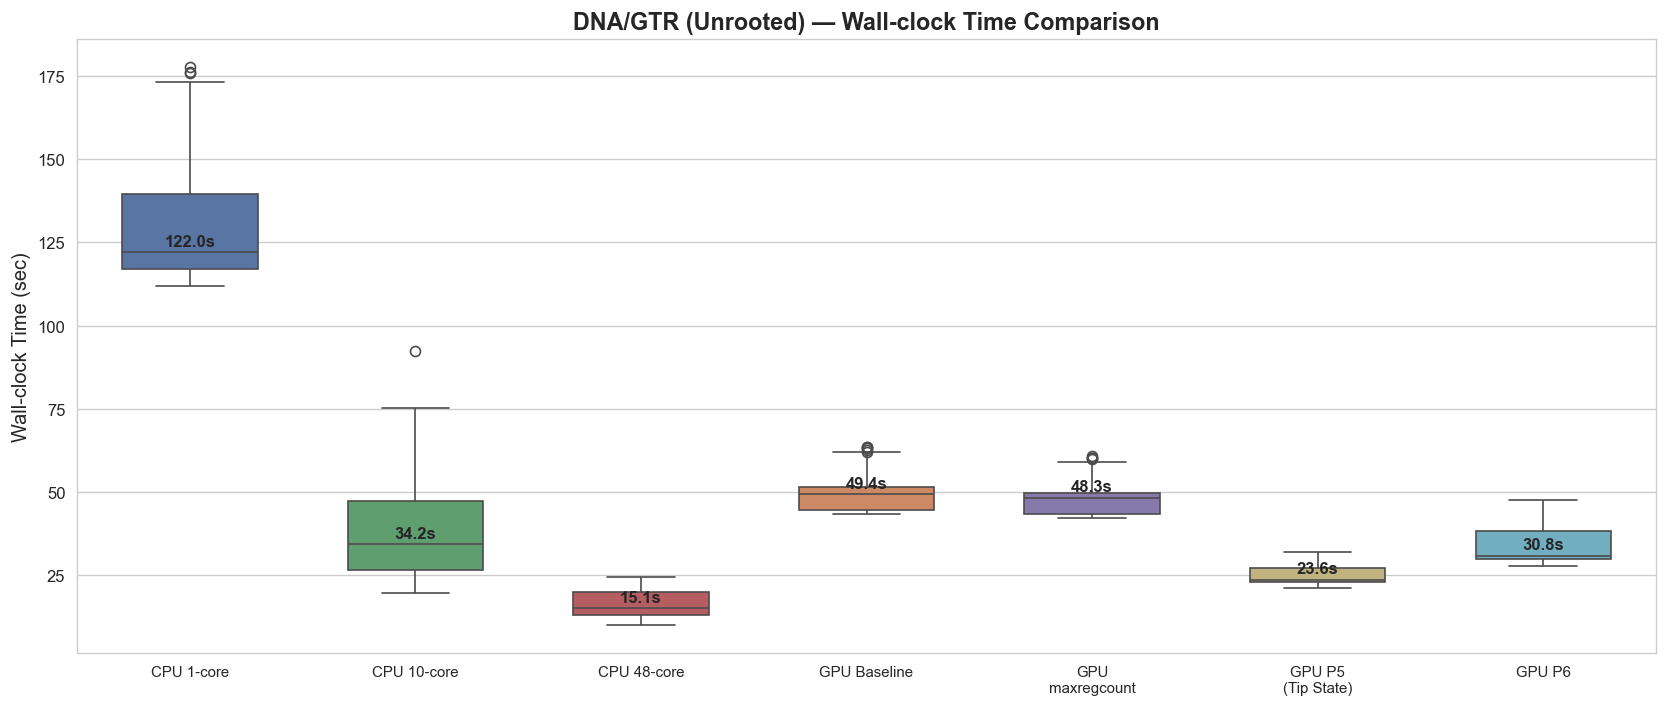

Saved: walltime_all_DNA_GTR.png


In [8]:
backend_order = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC', 'GPU_MAXREG', 'GPU_P5', 'GPU_P6']
backend_colors = {
    'VANILA': '#4C72B0', 'OMP_10': '#55A868', 'OMP_48': '#C44E52',
    'OPENACC': '#DD8452', 'GPU_MAXREG': '#8172B2',
    'GPU_P5': '#CCB974', 'GPU_P6': '#64B5CD'
}
backend_labels = {
    'VANILA': 'CPU 1-core', 'OMP_10': 'CPU 10-core', 'OMP_48': 'CPU 48-core',
    'OPENACC': 'GPU Baseline', 'GPU_MAXREG': 'GPU\nmaxregcount',
    'GPU_P5': 'GPU P5\n(Tip State)', 'GPU_P6': 'GPU P6'
}

for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model)]
    present = [b for b in backend_order if b in subset['backend'].unique()]
    palette = [backend_colors[b] for b in present]
    
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.boxplot(data=subset, x='backend', y='walltime',
               order=present, palette=palette, ax=ax, width=0.6)
    
    ax.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)
    ax.set_ylabel('Wall-clock Time (sec)', fontsize=12)
    ax.set_xlabel('')
    ax.set_title(f'{data_type}/{model} (Unrooted) — Wall-clock Time Comparison',
                fontsize=14, fontweight='bold')
    
    medians = subset.groupby('backend')['walltime'].median()
    for i, b in enumerate(present):
        if b in medians.index:
            ax.text(i, medians[b] + 1, f'{medians[b]:.1f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    fname = f'walltime_all_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 5. Speedup vs CPU 1-core

In [9]:
median_wt = df.groupby(['data_type', 'model', 'tree', 'backend'])['walltime'].median().reset_index()
pivot = median_wt.pivot_table(index=['data_type', 'model', 'tree'],
                               columns='backend', values='walltime').reset_index()

# Speedups vs VANILA
for b in ['OMP_10', 'OMP_48', 'OPENACC', 'GPU_MAXREG', 'GPU_P5', 'GPU_P6']:
    if b in pivot.columns and 'VANILA' in pivot.columns:
        pivot[f'speedup_{b}'] = pivot['VANILA'] / pivot[b]

# P6 vs other GPU
for ref in ['OPENACC', 'GPU_MAXREG', 'GPU_P5']:
    if ref in pivot.columns and 'GPU_P6' in pivot.columns:
        pivot[f'speedup_p6_vs_{ref}'] = pivot[ref] / pivot['GPU_P6']

pivot.to_csv(SAVE_DIR / 'speedup_pivot.csv', index=False)

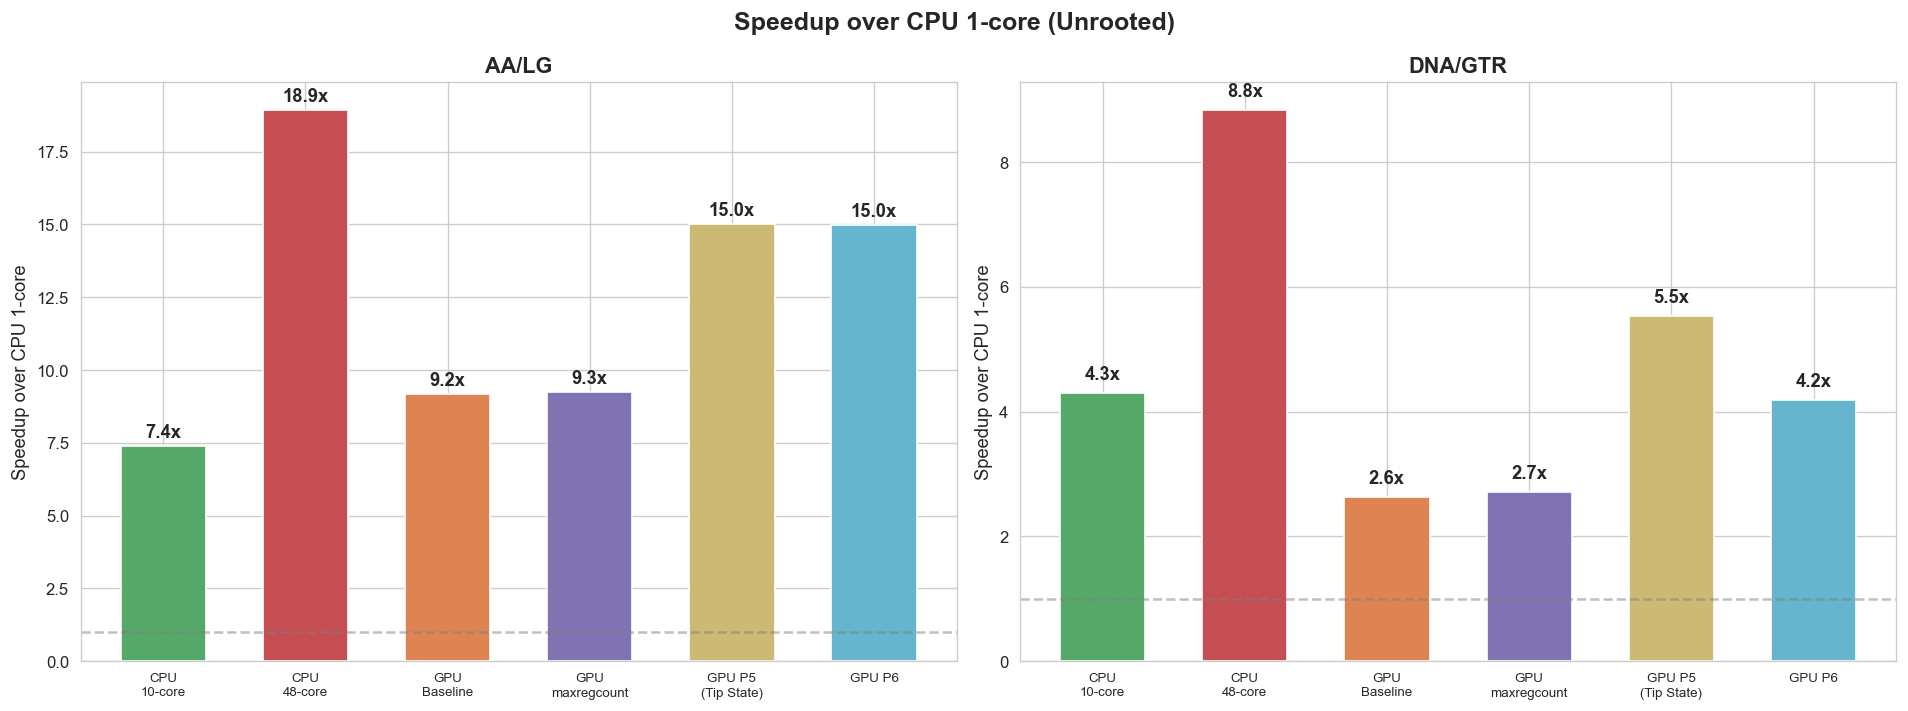

In [10]:
# Bar chart: speedup vs 1-core
speedup_backends = ['OMP_10', 'OMP_48', 'OPENACC', 'GPU_MAXREG', 'GPU_P5', 'GPU_P6']
bar_colors = ['#55A868', '#C44E52', '#DD8452', '#8172B2', '#CCB974', '#64B5CD']
bar_labels = ['CPU\n10-core', 'CPU\n48-core', 'GPU\nBaseline', 'GPU\nmaxregcount', 'GPU P5\n(Tip State)', 'GPU P6']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (data_type, model) in zip(axes, [('AA', 'LG'), ('DNA', 'GTR')]):
    sub = pivot[(pivot['data_type'] == data_type) & (pivot['model'] == model)]
    
    present_cols, present_colors, present_labels = [], [], []
    for b, c, l in zip(speedup_backends, bar_colors, bar_labels):
        col = f'speedup_{b}'
        if col in sub.columns and sub[col].notna().any():
            present_cols.append(col)
            present_colors.append(c)
            present_labels.append(l)
    
    means = [sub[c].mean() for c in present_cols]
    bars = ax.bar(range(len(present_cols)), means, color=present_colors, width=0.6)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
               f'{val:.1f}x', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_xticks(range(len(present_cols)))
    ax.set_xticklabels(present_labels, fontsize=8)
    ax.set_ylabel('Speedup over CPU 1-core', fontsize=11)
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{data_type}/{model}', fontsize=13, fontweight='bold')

fig.suptitle('Speedup over CPU 1-core (Unrooted)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'speedup_vs_1core.png', bbox_inches='tight')
plt.show()

## 6. GPU Evolution: Baseline → maxregcount → P5 → P6

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_18592/241300242.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_18592/241300242.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(p_labels, fontsize=10)


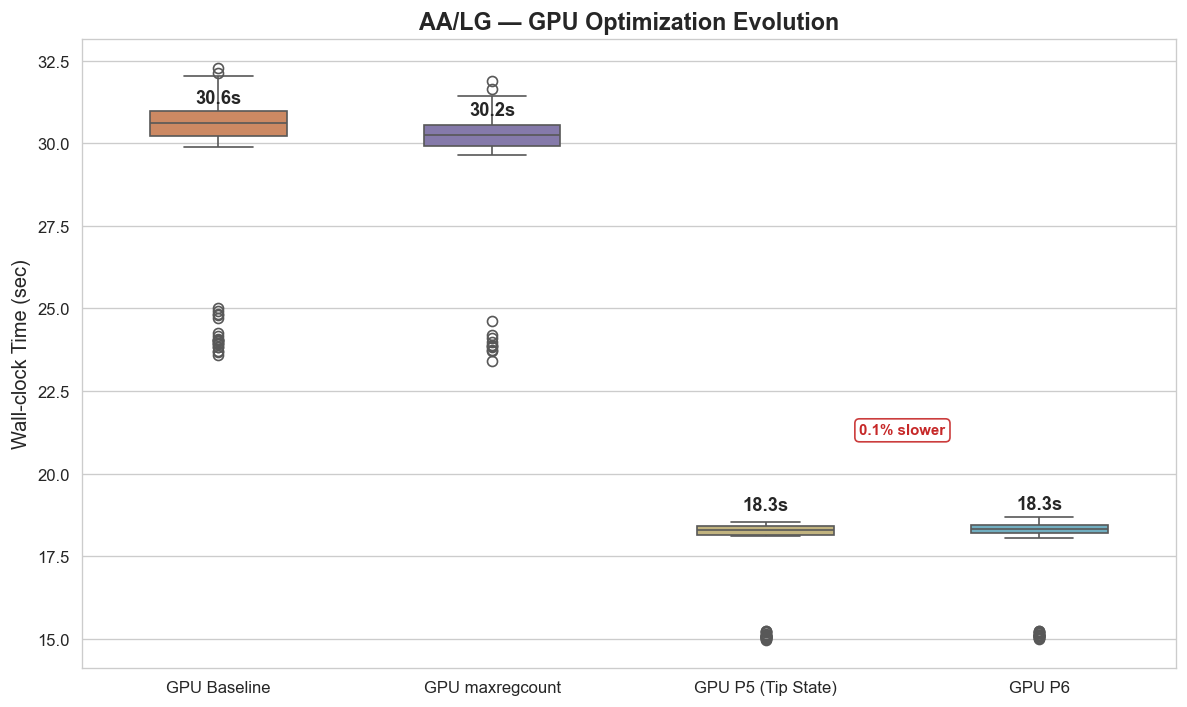

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_18592/241300242.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_18592/241300242.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(p_labels, fontsize=10)


Saved: gpu_evolution_AA_LG.png


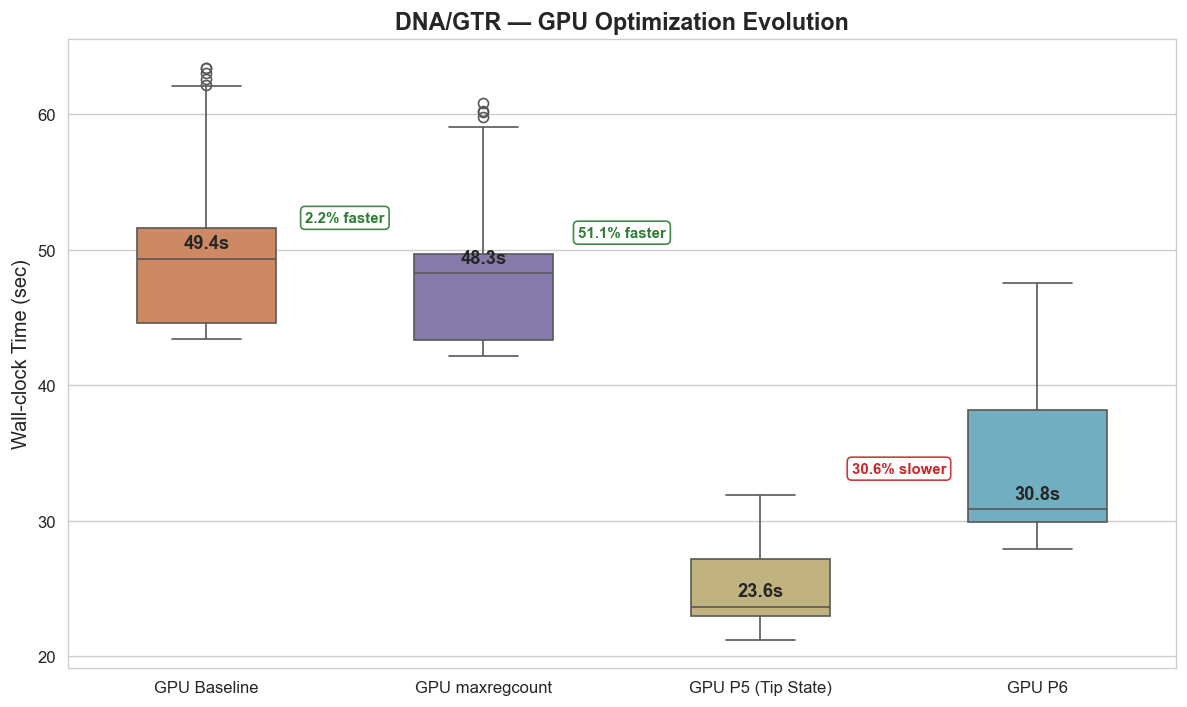

Saved: gpu_evolution_DNA_GTR.png


In [11]:
gpu_order = ['OPENACC', 'GPU_MAXREG', 'GPU_P5', 'GPU_P6']
gpu_labels = ['GPU Baseline', 'GPU maxregcount', 'GPU P5 (Tip State)', 'GPU P6']
gpu_colors = ['#DD8452', '#8172B2', '#CCB974', '#64B5CD']

for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model) &
               df['backend'].isin(gpu_order)]
    present = [b for b in gpu_order if b in subset['backend'].unique()]
    p_colors = [gpu_colors[gpu_order.index(b)] for b in present]
    p_labels = [gpu_labels[gpu_order.index(b)] for b in present]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=subset, x='backend', y='walltime',
               order=present, palette=p_colors, ax=ax, width=0.5)
    
    ax.set_xticklabels(p_labels, fontsize=10)
    ax.set_ylabel('Wall-clock Time (sec)', fontsize=12)
    ax.set_xlabel('')
    ax.set_title(f'{data_type}/{model} — GPU Optimization Evolution',
                fontsize=14, fontweight='bold')
    
    medians = subset.groupby('backend')['walltime'].median()
    for i, b in enumerate(present):
        if b in medians.index:
            ax.text(i, medians[b] + 0.5, f'{medians[b]:.1f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Improvement arrows between consecutive bars
    for i in range(len(present) - 1):
        if present[i] in medians.index and present[i+1] in medians.index:
            m1, m2 = medians[present[i]], medians[present[i+1]]
            pct = (m1 - m2) / m1 * 100
            mid_y = max(m1, m2) + 3
            color = '#2E7D32' if pct > 0 else '#C62828'
            sign = '+' if pct < 0 else ''
            label = f'{pct:.1f}% faster' if pct > 0 else f'{abs(pct):.1f}% slower'
            ax.annotate(label,
                       xy=(i + 0.5, mid_y), fontsize=9, fontweight='bold',
                       ha='center', va='center', color=color,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.9))
    
    plt.tight_layout()
    fname = f'gpu_evolution_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 7. P6 vs P5 — Direct Per-Tree Comparison

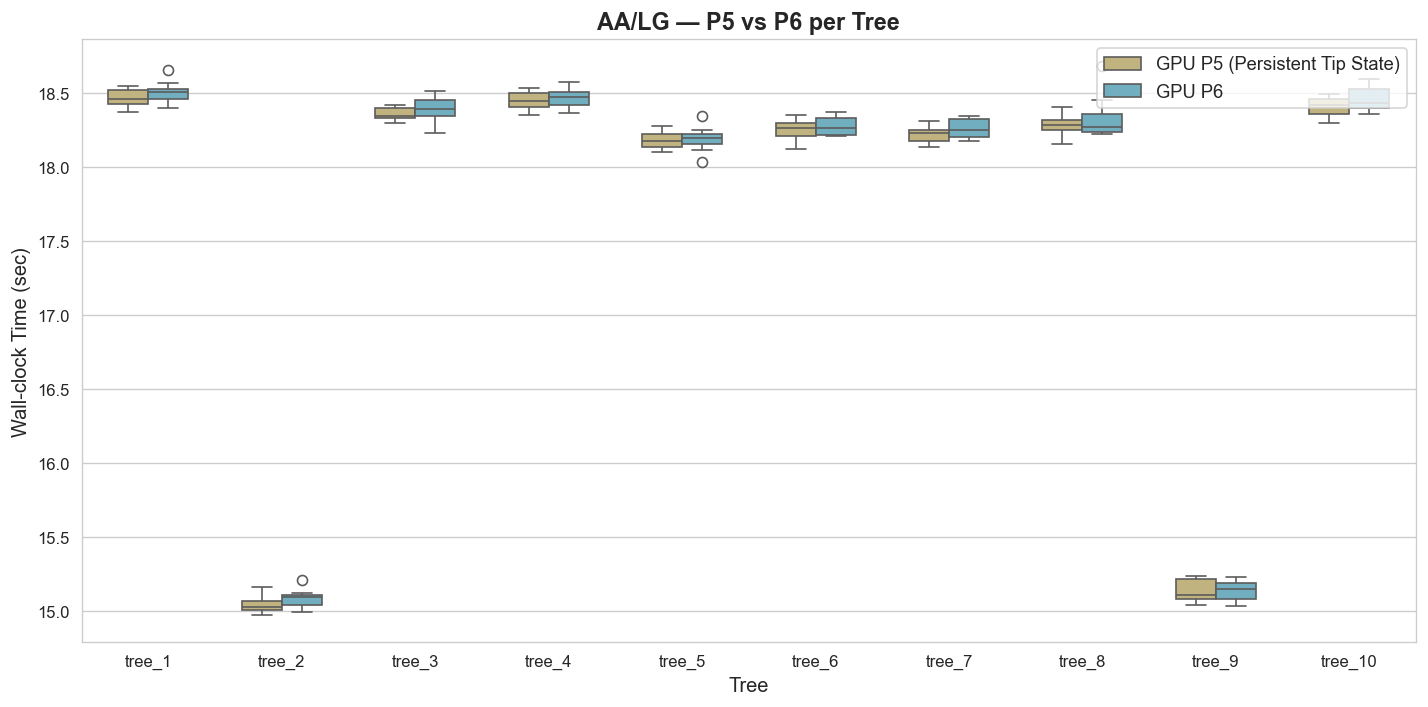

Saved: p5_vs_p6_AA_LG.png


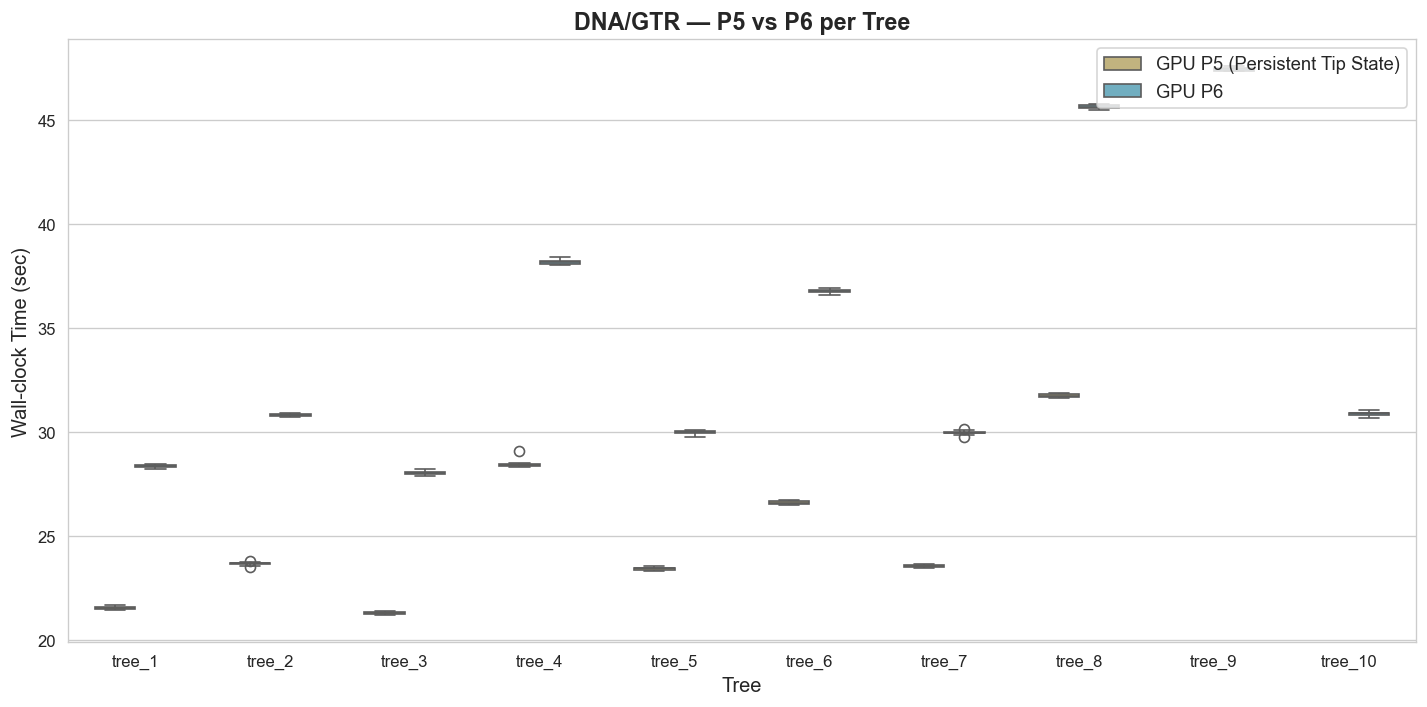

Saved: p5_vs_p6_DNA_GTR.png


In [12]:
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model) &
               df['backend'].isin(['GPU_P5', 'GPU_P6'])]
    if subset.empty: continue
    
    trees = sorted(subset['tree'].unique(), key=lambda x: int(x.split('_')[1]))
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=subset, x='tree', y='walltime', hue='backend',
               order=trees, hue_order=['GPU_P5', 'GPU_P6'],
               palette=[backend_colors['GPU_P5'], backend_colors['GPU_P6']],
               ax=ax, width=0.6)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['GPU P5 (Persistent Tip State)', 'GPU P6'], fontsize=11, loc='upper right')
    ax.set_xlabel('Tree', fontsize=12)
    ax.set_ylabel('Wall-clock Time (sec)', fontsize=12)
    ax.set_title(f'{data_type}/{model} — P5 vs P6 per Tree', fontsize=14, fontweight='bold')
    plt.tight_layout()
    fname = f'p5_vs_p6_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 8. Improvement: P6 vs GPU Baseline & P5 (per tree)

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_18592/3595165149.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
posx and posy should be finite values


posx and posy should be finite values


posx and posy should be finite values


posx and posy should be finite values


posx and posy should be finite values


...

posx and posy should be finite values


posx and posy should be finite values


posx and posy should be finite values


posx and posy should be finite values


posx and posy should be finite values


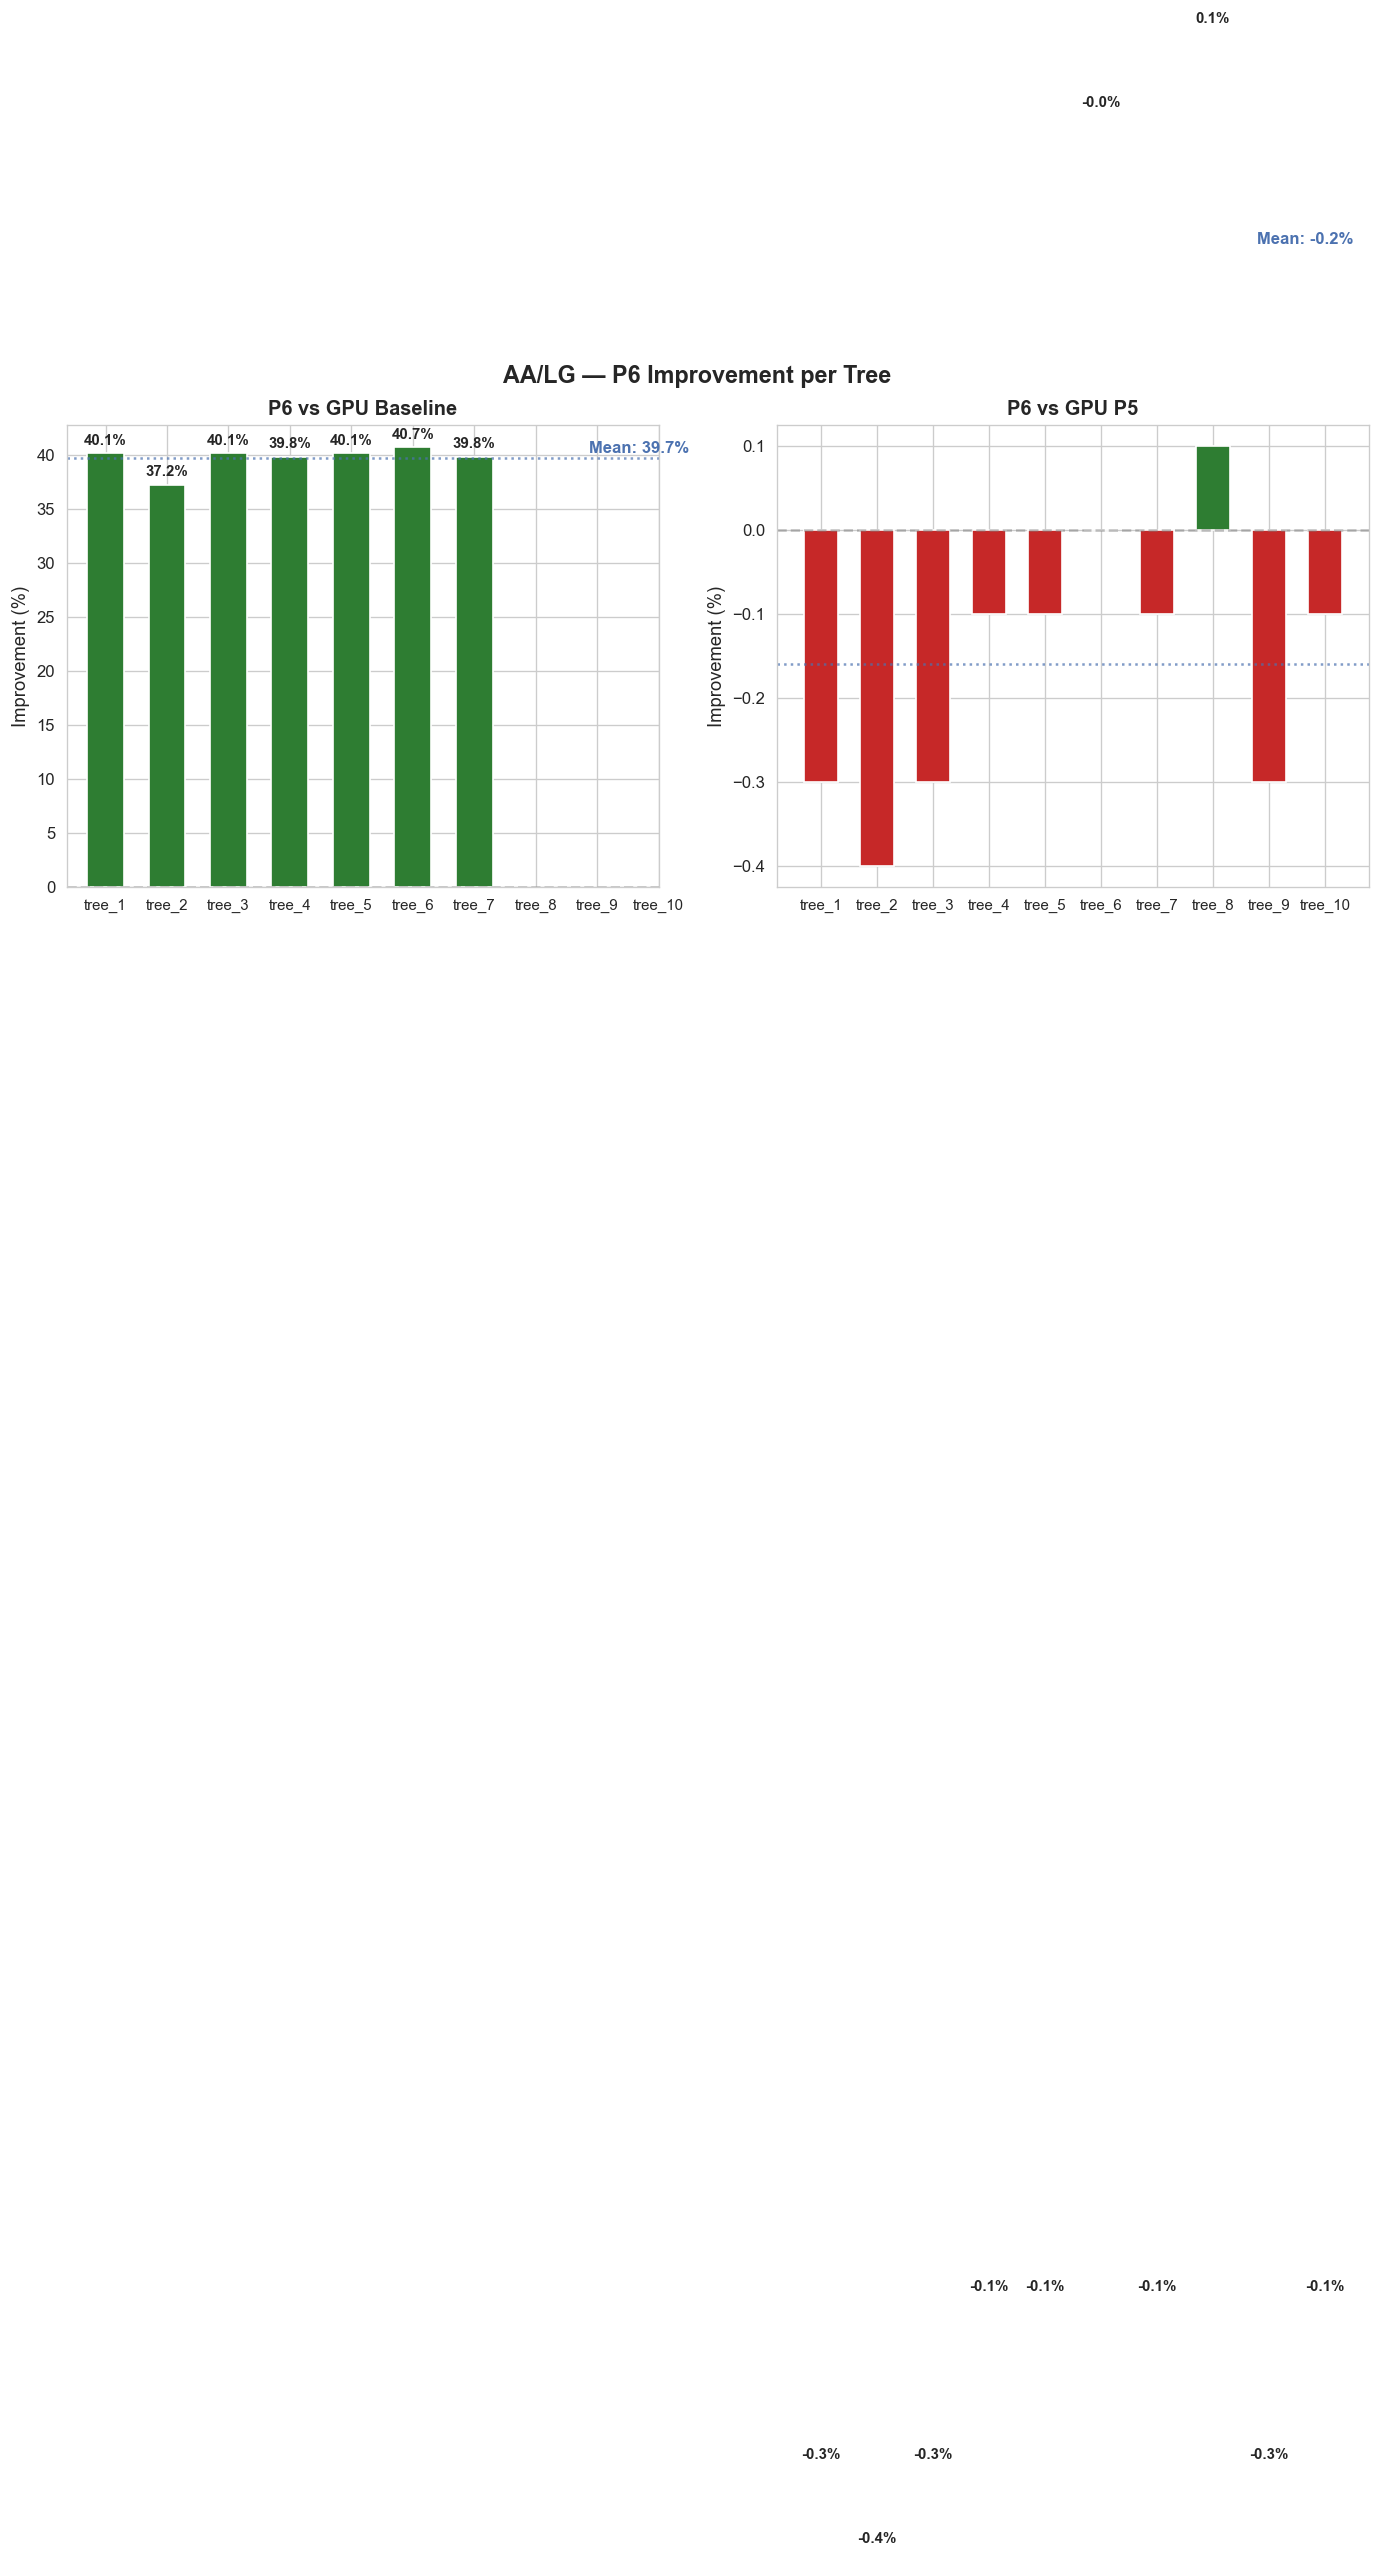

posx and posy should be finite values


posx and posy should be finite values


posx and posy should be finite values


posx and posy should be finite values


posx and posy should be finite values


...

posx and posy should be finite values


posx and posy should be finite values


posx and posy should be finite values


posx and posy should be finite values


posx and posy should be finite values


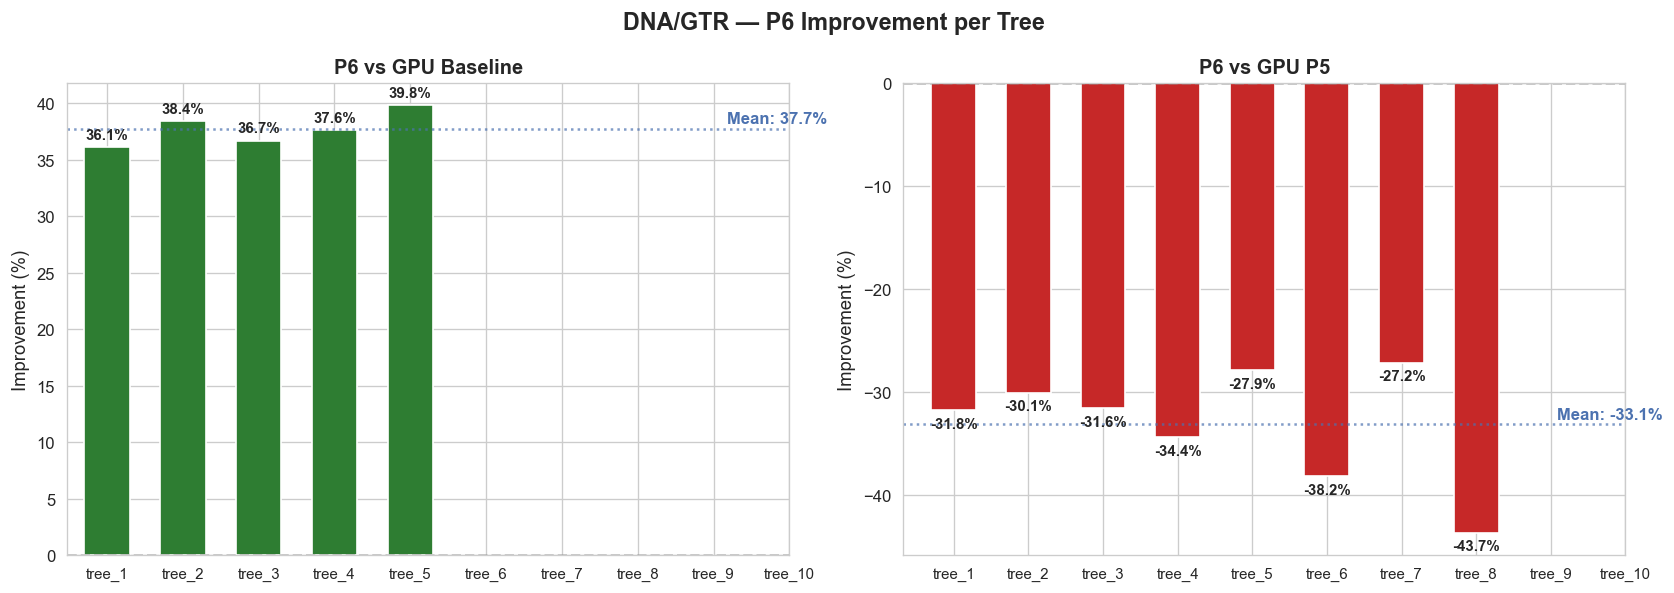

Saved: improvement_p6_DNA_GTR.png


In [13]:
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    sub = pivot[(pivot['data_type'] == data_type) & (pivot['model'] == model)].copy()
    if sub.empty: continue
    
    trees = sorted(sub['tree'].values, key=lambda x: int(x.split('_')[1]))
    sub_sorted = sub.set_index('tree').loc[trees]
    
    comparisons = []
    if 'OPENACC' in sub_sorted.columns and 'GPU_P6' in sub_sorted.columns:
        sub_sorted['imp_vs_baseline'] = ((sub_sorted['OPENACC'] - sub_sorted['GPU_P6']) / sub_sorted['OPENACC'] * 100).round(1)
        comparisons.append(('imp_vs_baseline', 'vs GPU Baseline', '#DD8452'))
    if 'GPU_P5' in sub_sorted.columns and 'GPU_P6' in sub_sorted.columns:
        sub_sorted['imp_vs_p5'] = ((sub_sorted['GPU_P5'] - sub_sorted['GPU_P6']) / sub_sorted['GPU_P5'] * 100).round(1)
        comparisons.append(('imp_vs_p5', 'vs GPU P5', '#CCB974'))
    
    if not comparisons: continue
    
    fig, axes = plt.subplots(1, len(comparisons), figsize=(7 * len(comparisons), 5))
    if len(comparisons) == 1: axes = [axes]
    
    for ax, (col, title, ref_color) in zip(axes, comparisons):
        vals = sub_sorted[col].values
        colors = ['#2E7D32' if v > 0 else '#C62828' for v in vals]
        bars = ax.bar(range(len(trees)), vals, color=colors, width=0.6)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                   bar.get_height() + (0.5 if val >= 0 else -2),
                   f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        mean_imp = np.nanmean(vals)
        ax.axhline(y=mean_imp, color='#4C72B0', linestyle=':', alpha=0.7)
        ax.text(len(trees) - 0.5, mean_imp + 0.5, f'Mean: {mean_imp:.1f}%',
               fontsize=10, color='#4C72B0', fontweight='bold', ha='right')
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xticks(range(len(trees)))
        ax.set_xticklabels(trees, fontsize=9)
        ax.set_ylabel('Improvement (%)', fontsize=11)
        ax.set_title(f'P6 {title}', fontsize=12, fontweight='bold')
    
    fig.suptitle(f'{data_type}/{model} — P6 Improvement per Tree', fontsize=14, fontweight='bold')
    plt.tight_layout()
    fname = f'improvement_p6_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 9. Optimization Time — GPU Evolution

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_18592/3506121893.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_18592/3506121893.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(p_labels, fontsize=10)


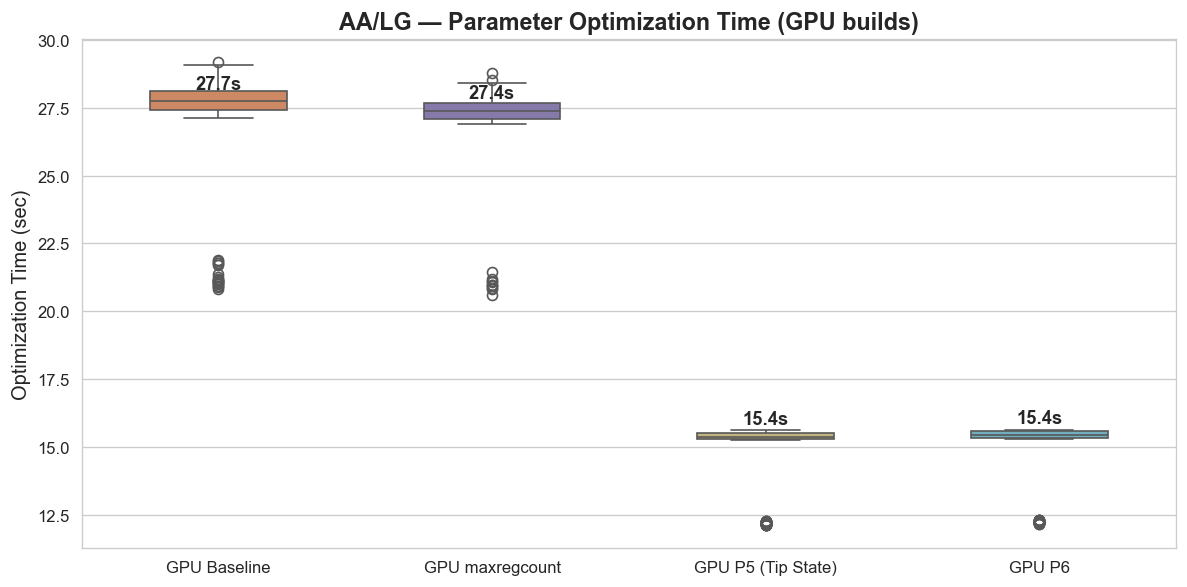

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_18592/3506121893.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_18592/3506121893.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(p_labels, fontsize=10)


Saved: opt_time_gpu_AA_LG.png


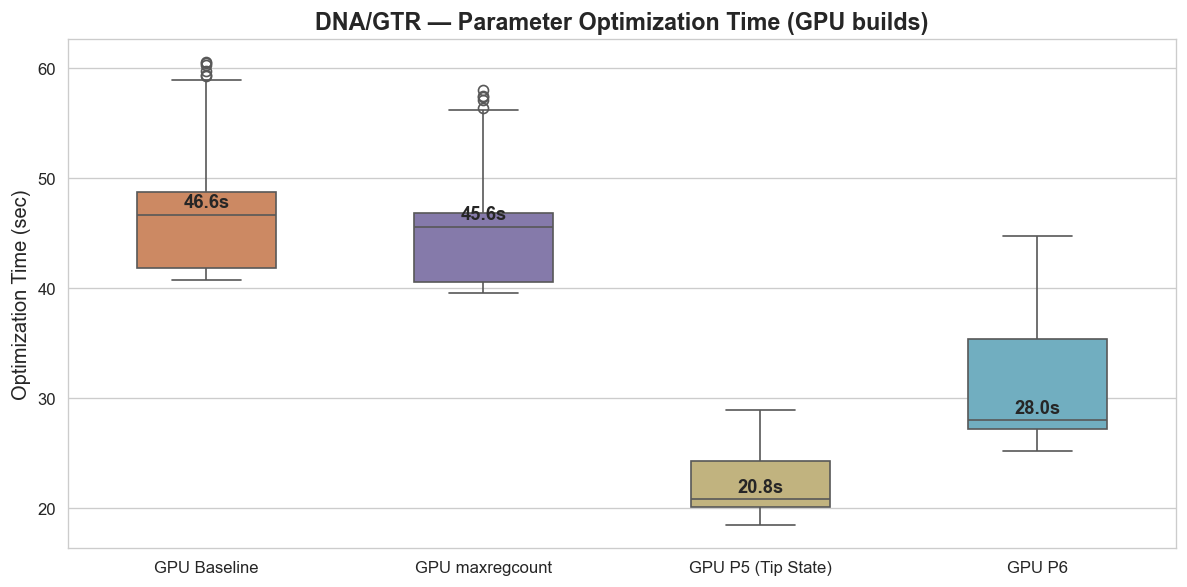

Saved: opt_time_gpu_DNA_GTR.png


In [14]:
gpu_all = df[df['backend'].isin(gpu_order)].dropna(subset=['opt_time'])

for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = gpu_all[(gpu_all['data_type'] == data_type) & (gpu_all['model'] == model)]
    present = [b for b in gpu_order if b in subset['backend'].unique()]
    p_colors = [gpu_colors[gpu_order.index(b)] for b in present]
    p_labels = [gpu_labels[gpu_order.index(b)] for b in present]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=subset, x='backend', y='opt_time',
               order=present, palette=p_colors, ax=ax, width=0.5)
    ax.set_xticklabels(p_labels, fontsize=10)
    ax.set_ylabel('Optimization Time (sec)', fontsize=12)
    ax.set_xlabel('')
    ax.set_title(f'{data_type}/{model} — Parameter Optimization Time (GPU builds)',
                fontsize=14, fontweight='bold')
    
    medians = subset.groupby('backend')['opt_time'].median()
    for i, b in enumerate(present):
        if b in medians.index:
            ax.text(i, medians[b] + 0.3, f'{medians[b]:.1f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    fname = f'opt_time_gpu_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 10. Per-Tree All Backends Bar Chart

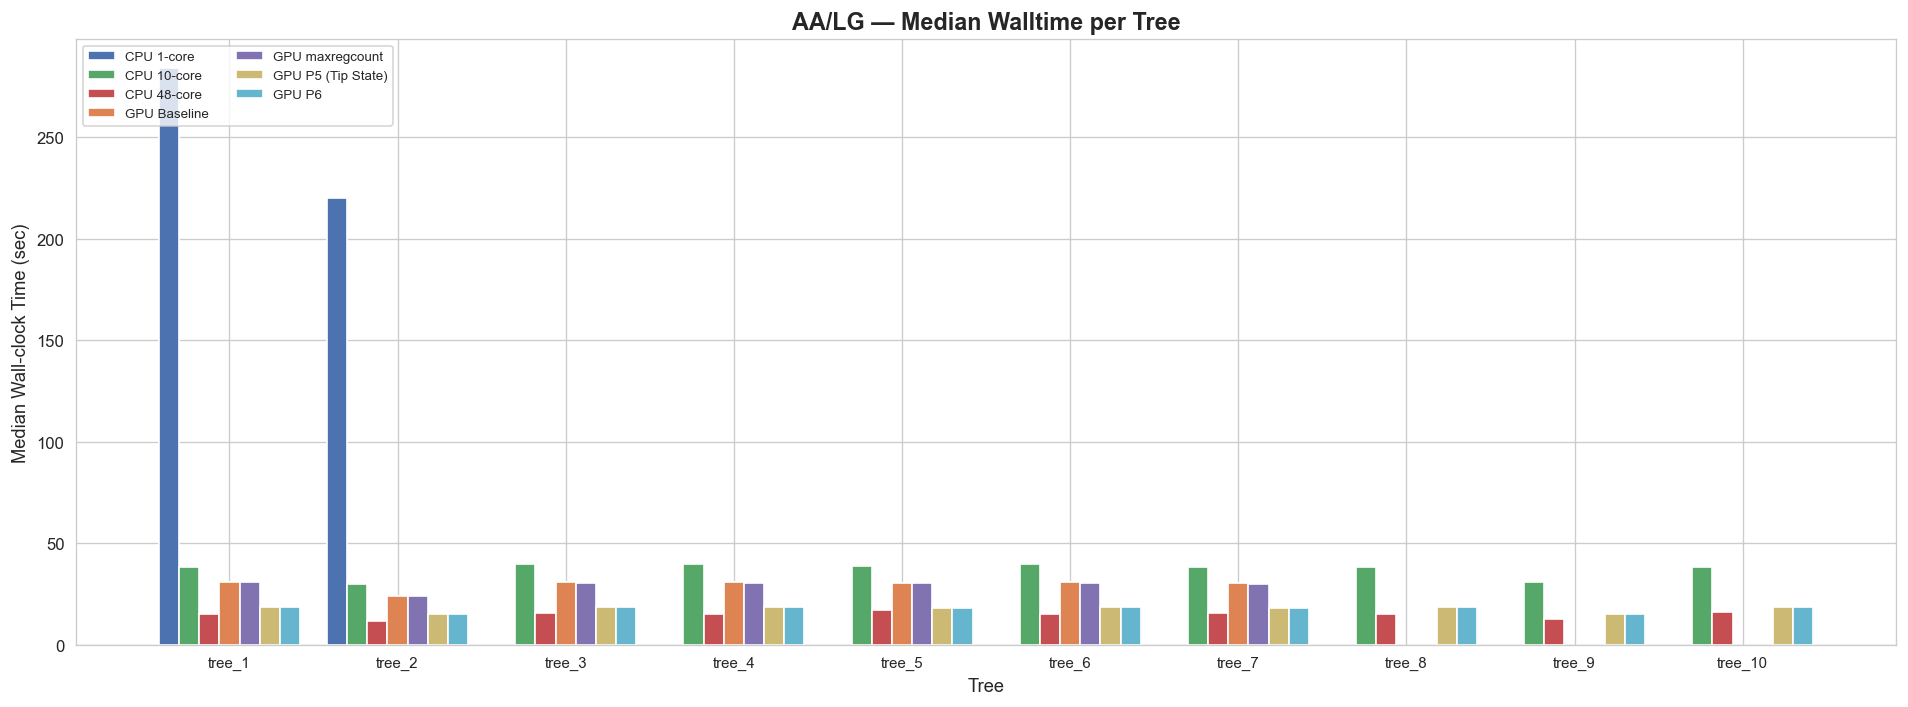

Saved: per_tree_all_AA_LG.png


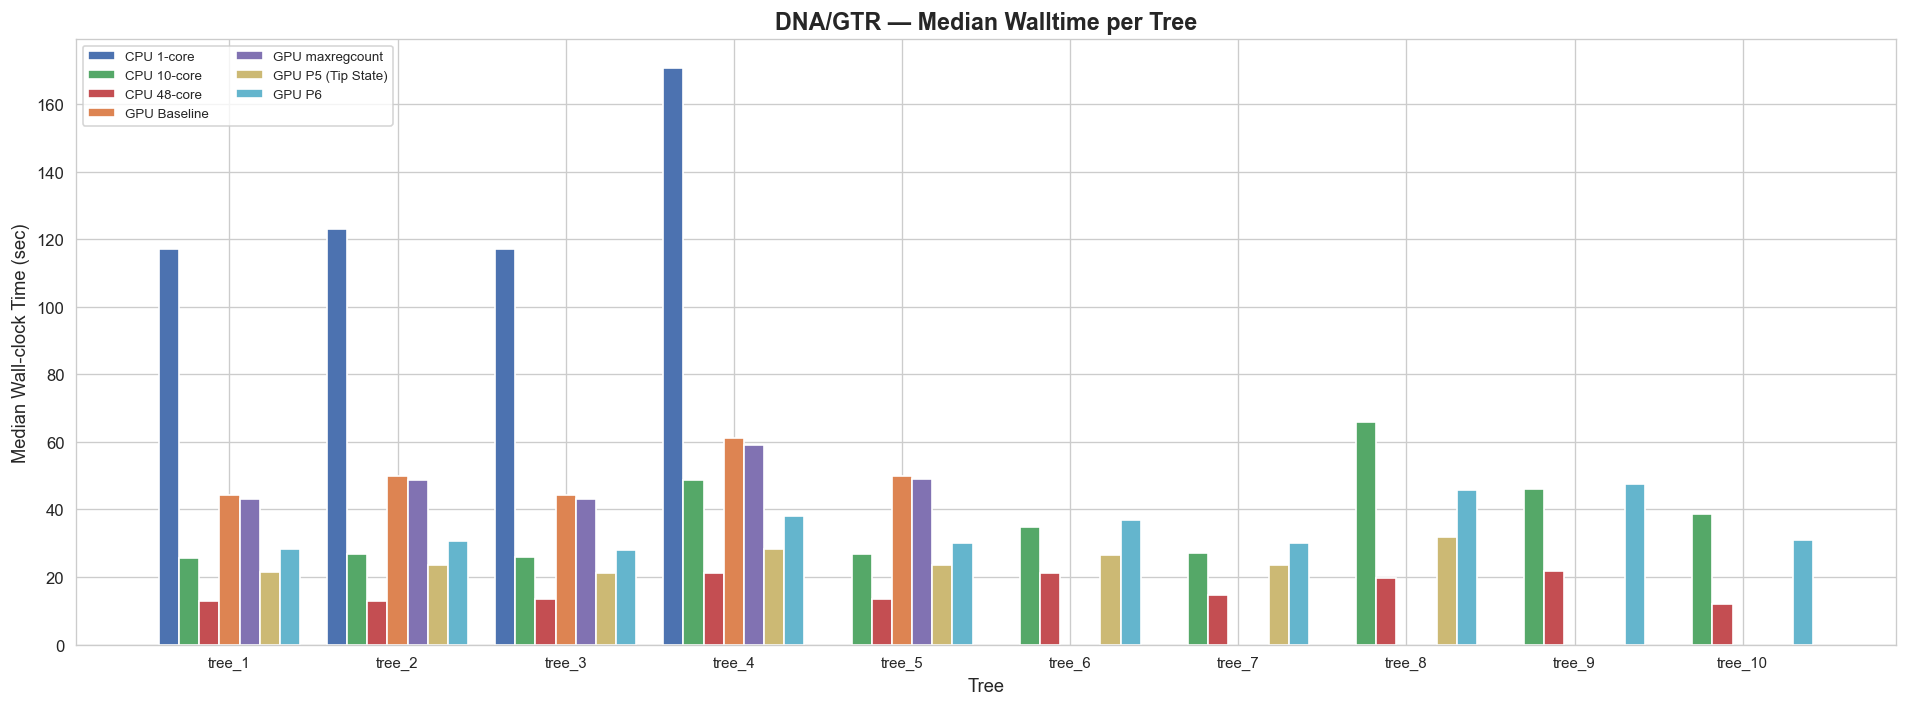

Saved: per_tree_all_DNA_GTR.png


In [15]:
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model)]
    present = [b for b in backend_order if b in subset['backend'].unique()]
    trees = sorted(subset['tree'].unique(), key=lambda x: int(x.split('_')[1]))
    
    tree_medians = subset.groupby(['tree', 'backend'])['walltime'].median().reset_index()
    tree_pivot = tree_medians.pivot_table(index='tree', columns='backend', values='walltime').reindex(trees)
    
    fig, ax = plt.subplots(figsize=(16, 6))
    x = np.arange(len(trees))
    width = 0.12
    
    for i, b in enumerate(present):
        if b in tree_pivot.columns:
            ax.bar(x + i * width, tree_pivot[b].values, width,
                  label=backend_labels.get(b, b).replace('\n', ' '), color=backend_colors[b])
    
    ax.set_xticks(x + width * (len(present) - 1) / 2)
    ax.set_xticklabels(trees, fontsize=9)
    ax.set_ylabel('Median Wall-clock Time (sec)', fontsize=11)
    ax.set_xlabel('Tree', fontsize=11)
    ax.legend(fontsize=8, ncol=2)
    ax.set_title(f'{data_type}/{model} — Median Walltime per Tree', fontsize=14, fontweight='bold')
    plt.tight_layout()
    fname = f'per_tree_all_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 11. Final Summary Table

In [16]:
final = df.groupby(['data_type', 'model', 'backend']).agg(
    mean_walltime=('walltime', 'mean'),
    median_walltime=('walltime', 'median'),
    std_walltime=('walltime', 'std'),
    mean_opt_time=('opt_time', 'mean'),
    mean_logl=('log_likelihood', 'mean'),
    mean_tree_length=('tree_length', 'mean'),
    n_runs=('walltime', 'count')
).round(2).reset_index()

# Speedup vs 1-core
vanila = final[final['backend'] == 'VANILA'][['data_type', 'model', 'median_walltime']].rename(
    columns={'median_walltime': 'ref'})
final = final.merge(vanila, on=['data_type', 'model'], how='left')
final['speedup_vs_1core'] = (final['ref'] / final['median_walltime']).round(2)
final.drop(columns='ref', inplace=True)

# Speedup vs baseline GPU
gpu_base = final[final['backend'] == 'OPENACC'][['data_type', 'model', 'median_walltime']].rename(
    columns={'median_walltime': 'ref'})
final = final.merge(gpu_base, on=['data_type', 'model'], how='left')
final['speedup_vs_gpu_base'] = (final['ref'] / final['median_walltime']).round(2)
final.drop(columns='ref', inplace=True)

# Speedup vs P5
gpu_p5 = final[final['backend'] == 'GPU_P5'][['data_type', 'model', 'median_walltime']].rename(
    columns={'median_walltime': 'ref'})
final = final.merge(gpu_p5, on=['data_type', 'model'], how='left')
final['speedup_vs_P5'] = (final['ref'] / final['median_walltime']).round(2)
final.drop(columns='ref', inplace=True)

final.to_csv(SAVE_DIR / 'final_summary.csv', index=False)

display(final.style.format({
    'speedup_vs_1core': '{:.2f}x',
    'speedup_vs_gpu_base': '{:.2f}x',
    'speedup_vs_P5': '{:.2f}x',
    'mean_logl': '{:.3f}'
}).background_gradient(subset=['speedup_vs_1core'], cmap='Greens')
 .background_gradient(subset=['speedup_vs_gpu_base'], cmap='Oranges')
 .background_gradient(subset=['speedup_vs_P5'], cmap='Purples'))

,data_type,model,backend,mean_walltime,median_walltime,std_walltime,mean_opt_time,mean_logl,mean_tree_length,n_runs,speedup_vs_1core,speedup_vs_gpu_base,speedup_vs_P5
0,AA,LG,GPU_MAXREG,29.490000,30.250000,2.330000,26.590000,-87470599.180,19.720000,70,8.27x,1.01x,0.60x
1,AA,LG,GPU_P5,17.670000,18.290000,1.310000,14.800000,-86324112.640,19.350000,99,13.68x,1.67x,1.00x
2,AA,LG,GPU_P6,17.710000,18.310000,1.310000,14.850000,-86328013.800,19.350000,100,13.67x,1.67x,1.00x
3,AA,LG,OMP_10,40.600000,38.560000,9.580000,39.260000,-86328013.800,19.350000,100,6.49x,0.79x,0.47x
4,AA,LG,OMP_48,15.460000,15.020000,2.400000,14.030000,-86328013.800,19.350000,100,16.66x,2.04x,1.22x
5,AA,LG,OPENACC,29.860000,30.600000,2.430000,26.950000,-87477966.390,19.720000,137,8.18x,1.00x,0.60x
6,AA,LG,VANILA,251.790000,250.290000,33.780000,248.780000,-89703067.780,20.130000,20,1.00x,0.12x,0.07x
7,DNA,GTR,GPU_MAXREG,48.680000,48.260000,5.990000,45.920000,-66837691.060,19.750000,50,2.53x,1.02x,0.49x
8,DNA,GTR,GPU_P5,25.050000,23.620000,3.410000,22.240000,-66557528.130,19.490000,80,5.17x,2.09x,1.00x
9,DNA,GTR,GPU_P6,34.600000,30.840000,6.790000,31.800000,-67437010.890,19.910000,100,3.96x,1.60x,0.77x
